# Feature Extraction

A feature extractor turns an image into a grid of vectors, one per small image patch. Patches
that show similar things get similar vectors. Talk2DINO and MaskCLIP also turn text into a vector
of the same kind, so a word can be compared with every patch. This page runs both on one frame.

In [1]:
import matplotlib.pyplot as plt
import transformers

from collab_splats.semantics import MaskCLIPExtractor, Talk2DinoExtractor
from collab_splats.utils.io import read_image
from collab_splats.utils.notebook import feature_viz_row

%run ../tutorial.py

# Hide a harmless checkpoint warning from Talk2DINO
transformers.logging.set_verbosity_error()

frame = read_image(QUERY_IMAGE)

## 1. Features and a text query

`forward` returns one feature map per image. `score_queries` compares each patch with the query
word and with a few negative words, and gives each patch a score from 0 to 1. Naming the other
things in the scene as negatives makes the query stand out; against "object" alone, "tree" wins
almost everywhere in a forest.

Extract features and score "tree" with both extractors:

In [2]:
QUERY = "tree"
NEGATIVES = ["object", "background", "ground", "sky"]

extractors = {"Talk2DINO": Talk2DinoExtractor(), "MaskCLIP": MaskCLIPExtractor()}
maps = {}
scores = {}

for name, extractor in extractors.items():
    maps[name] = extractor.forward([frame])[0]
    score = extractor.score_queries(maps[name], positive=[QUERY], negative=NEGATIVES)
    scores[name] = score.cpu().numpy()
    print(f"{name}: {maps[name].shape[0]}-D features on a {tuple(maps[name].shape[1:])} grid")

Talk2DINO: 768-D features on a (18, 32) grid


MaskCLIP: 768-D features on a (41, 73) grid


The patch grid is much coarser than the image, so the maps below are blocky.

## 2. What the features show

One row per extractor:

- PCA colors: the features squeezed to three colors. Similar colors mean similar features,
  so objects should appear as patches of one color.
- Heatmap (viridis): the score for "tree"; yellow matches the word, dark does not.
- Masked: the image kept only where the score is high.

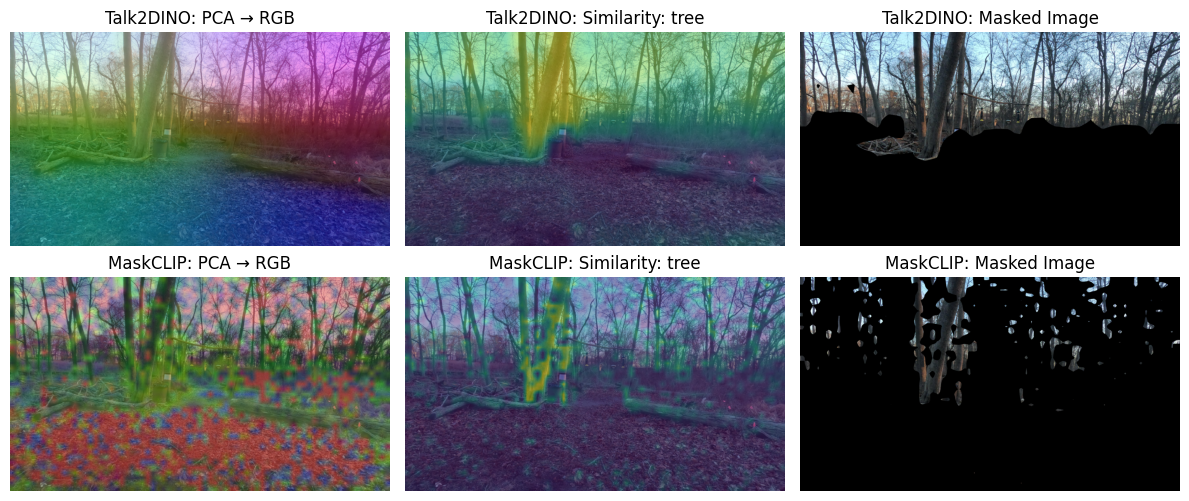

In [3]:
fig, axes = plt.subplots(len(extractors), 3, figsize=(12, 2.6 * len(extractors)))

for row, name in enumerate(extractors):
    feature_viz_row(
        axes[row],
        frame,
        maps[name],
        scores[name],
        title_prefix=f"{name}: ",
        query_label=QUERY,
    )

plt.tight_layout()

A good extractor lights up the trees and stays dark elsewhere, with edges that follow the trunks.

## In a pipeline run

The `semantics` stage runs each listed extractor over every keyframe and lifts the features onto the
mesh (see the lifting and query page). The tutorial scene uses Talk2DINO:

```yaml
semantics:
  enabled: true
  extractors: [talk2dino]    # any of talk2dino | dinov2 | maskclip | ocr_lens
```